In [1]:
# installations
import sys

!{sys.executable} -m pip install -U pip setuptools wheel
!{sys.executable} -m pip install -U spacy
!{sys.executable} -m pip -m spacy download en_core_web_sm
!{sys.executable} -m pip install jiwer pandas -U

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable

Usage:   
  /usr/bin/python3 -m pip <command> [options]

no such option: -m
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import spacy
from jiwer import compute_measures, RemovePunctuation
import pandas as pd
import json
import re

SPACY_MODEL = "en_core_web_sm"
nlp = spacy.load(SPACY_MODEL)
path = "../Documents/thesis/chat-gpt-asr/results/results-dev-set/results_noisy/results_tiny/results_sentence_confidence_tiny/results_GPT-3.5-Turbo_tiny/gpt-3.5-turbo-0125/results_without_sentence_confidence_tiny/corrected_transcriptions_sentence_confidence_tiny.json"


In [3]:
def read_data(path):
    # dummy data
    #  data = [
    #     ("The cat sat on the mat.", "The cat sat, on the mat.", "The cat is sitting on the mat."),
    #     ("He walks to the store.", "He walk to the store.", "He walked to the store."),
    #     ("She plays piano very well.", "She play piano very well.", "She plays the piano very well."),
    #     ("I don't go to school", "I don't go to school and", "I go to school.")
    # ]
    with open(path, "r") as f:
        data = json.load(f)
    
    transcriptions = [d["asr_transcription"]["text"] for d in data]
    corrected_transcriptions = [d["corrected_asr_transcription"] for d in data]
    reference_transcriptions = [d["reference_transcription"] for d in data]
    
    assert all([type(r) == str for r in transcriptions]) == True, "transcriptions should be a list of str!"
    assert all([type(r) == str for r in corrected_transcriptions]) == True, "transcriptions should be a list of str!"
    assert all([type(r) == str for r in reference_transcriptions]) == True, "transcriptions should be a list of str!"
    
    return transcriptions, corrected_transcriptions, reference_transcriptions

In [4]:
def wrapper(remove_punct=True, return_texts=False, return_pos=False):
    def tokenizer_fn(texts):
        tokens = []
        texts_new = []
        poses = []
        for text in texts:
            if remove_punct:
                # remove punctuation
                text = re.sub("[\s]+", " ", text).strip().lower()
                tokens.append([token.text for token in nlp(text) if token.pos_ != "PUNCT"])
                poses.append([token.pos_ for token in nlp(text) if token.pos_ != "PUNCT"])
                text = "".join([token.text_with_ws if token.pos_ != "PUNCT" else " "  for token in nlp(text) ])
                text = re.sub("[\s]+", " ", text).strip().lower()
                # text = RemovePunctuation()(text.lower().strip())
                texts_new.append(text)
            else:
                text = re.sub("[\s]+", " ", text).strip().lower()
                tokens.append([token.text for token in nlp(text)])
                poses.append([token.pos_ for token in nlp(text)])
                text = "".join([token.text_with_ws for token in nlp(text) ])
                text = re.sub("[\s]+", " ", text).strip().lower()
                texts_new.append(text)

        if (return_texts == False) and (return_pos == False):
            return tokens
            
        out = [tokens, None, None]
        if return_texts:
            out[1] = texts_new
        if return_pos:
            out[2] = poses
        return out
        
    return tokenizer_fn

In [5]:
def extract_words(measures):

    truths_pos, hypotheses_pos, ops, truths, hypotheses = measures['truth_pos'], measures['hypothesis_pos'], measures['ops'], \
                                            measures['truth'], measures['hypothesis']
    n_samples = len(truths)
    words = [[] for i in range(n_samples)]
    pos = [[] for i in range(n_samples)]
    operations = [[] for i in range(n_samples)]
    
    for idx in range(n_samples):
        truth_pos = truths_pos[idx]
        truth = truths[idx]

        hypothesis = hypotheses[idx]
        hypothesis_pos = hypotheses_pos[idx]

        for op in ops[idx]:
            if op.type == "delete":
                words[idx].extend(truth[op.ref_start_idx:op.ref_end_idx])
                pos[idx].extend(truth_pos[op.ref_start_idx:op.ref_end_idx])
                operations[idx].extend(["delete" for _ in truth_pos[op.ref_start_idx:op.ref_end_idx]])
                
            elif op.type == "insert":
                words[idx].extend(hypothesis[op.hyp_start_idx:op.hyp_end_idx])
                pos[idx].extend(hypothesis_pos[op.hyp_start_idx:op.hyp_end_idx])
                operations[idx].extend(["insert" for _ in hypothesis_pos[op.hyp_start_idx:op.hyp_end_idx]])
                
            elif op.type == "substitute":
                # words[idx].extend(truth_text[op.ref_start_idx:op.ref_end_idx])
                # pos[idx].extend(truth_pos[op.ref_start_idx:op.ref_end_idx])
                words[idx].extend(hypothesis[op.hyp_start_idx:op.hyp_end_idx])
                pos[idx].extend(hypothesis_pos[op.hyp_start_idx:op.hyp_end_idx])
                operations[idx].extend(["substitute" for _ in hypothesis_pos[op.hyp_start_idx:op.hyp_end_idx]])
                
            elif op.type == "equal":
                # words[idx].extend(truth_text[op.ref_start_idx:op.ref_end_idx])
                # pos[idx].extend(truth_pos[op.ref_start_idx:op.ref_end_idx])
                words[idx].extend(hypothesis[op.hyp_start_idx:op.hyp_end_idx])
                pos[idx].extend(hypothesis_pos[op.hyp_start_idx:op.hyp_end_idx])
                operations[idx].extend(["equal" for _ in hypothesis_pos[op.hyp_start_idx:op.hyp_end_idx]])

    return words, pos, operations

In [6]:
def create_table(pos, ops):
    # Flatten the nested lists of pos and ops
    flat_pos = [pos_row for sublist in pos for pos_row in sublist]
    flat_ops = [ops_row for sublist in operations for ops_row in sublist]

    # Get unique parts of speech
    unique_pos = sorted(set(flat_pos))
    unique_ops = set(flat_ops)
    # Create a dictionary to store the cumulative sums for each operation and part of speech
    data = {op: {p: sum(1 for i, j in zip(flat_pos, flat_ops) if i == p and j == op) for p in unique_pos} for op in unique_ops}

    # Convert the dictionary into a DataFrame
    df = pd.DataFrame(data)

    return df.T

In [7]:
def create_table_wide(pos, operations):
    # Flatten the nested lists of pos and ops
    flat_pos = [pos_row for sublist in pos for pos_row in sublist]
    flat_ops = [ops_row for sublist in operations for ops_row in sublist]

    # Get unique parts of speech
    unique_pos = sorted(set(flat_pos))
    unique_ops = set(flat_ops)
    unique_ops.difference_update({'equal'})

    # Create an empty DataFrame
    df = pd.DataFrame(index=range(len(pos)), columns=[(op, pos_) for op in unique_ops for pos_ in unique_pos])
    
    # Iterate over the examples, counting occurrences of each unique combination
    for i, (p, o) in enumerate(zip(pos, operations)):
        for pos_, op in zip(p, o):
            if (op, pos_) in df.columns:
                df.at[i, (op, pos_)] = df.at[i, (op, pos_)] + 1 if not pd.isna(df.at[i, (op, pos_)]) else 1
    
    # Fill missing values with zeros
    df.fillna(0, inplace=True)
    return df


In [8]:
# __main__

# read data
transcriptions, corrected_transcriptions, reference_transcriptions = read_data(path)

# compute measures
meas = compute_measures(transcriptions, corrected_transcriptions, 
                truth_transform=wrapper(), hypothesis_transform=wrapper())
trans_tokens, trans_texts, trans_poses = wrapper(return_texts=True,return_pos=True)(transcriptions)
c_trans_tokens, c_trans_texts, c_trans_poses = wrapper(return_texts=True,return_pos=True)(corrected_transcriptions)
meas['truth_pos'] = trans_poses 
meas['hypothesis_pos'] = c_trans_poses 

# extract changed words and poses
words, pos, operations = extract_words(meas)

# create table
df = create_table(pos, operations)

# convert to percentage
df = (df.div(df.sum(axis=1), axis=0)*100).round(2)

# remove unimportant columns (poses)
condition = df.sum(axis=0) < 2
columns_to_delete = [k for k,v in dict(condition).items() if v]
df_short = df.drop(columns=columns_to_delete)
# df.to_markdown(output)
df

,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PART,PRON,PROPN,SCONJ,SYM,VERB,X
substitute,9.73,6.05,5.20,2.42,1.35,2.78,0.18,35.07,0.54,2.74,4.98,6.46,1.26,0.0,21.26,0.00
equal,6.54,11.14,5.99,7.44,4.39,9.64,0.43,17.21,0.64,3.21,14.47,2.67,2.84,0.0,13.36,0.01
delete,3.42,14.82,4.72,7.00,1.79,9.45,0.49,26.55,0.16,5.86,8.31,4.23,1.30,0.0,10.75,1.14
insert,4.24,14.41,2.12,8.90,0.85,13.56,0.00,18.64,0.85,7.20,8.90,8.90,2.12,0.0,9.32,0.00


In [9]:
k = df.shape[1] - 1
selected_ops = ['delete','substitute','insert']
sorted_sum_of_selected_ops = df.loc[selected_ops].sum().sort_values(ascending=False)
df[sorted_sum_of_selected_ops.index[:k]]

,NOUN,VERB,ADP,DET,PRON,PROPN,AUX,ADJ,PART,ADV,SCONJ,CCONJ,NUM,X,INTJ
substitute,35.07,21.26,6.05,2.78,4.98,6.46,2.42,9.73,2.74,5.20,1.26,1.35,0.54,0.00,0.18
equal,17.21,13.36,11.14,9.64,14.47,2.67,7.44,6.54,3.21,5.99,2.84,4.39,0.64,0.01,0.43
delete,26.55,10.75,14.82,9.45,8.31,4.23,7.00,3.42,5.86,4.72,1.30,1.79,0.16,1.14,0.49
insert,18.64,9.32,14.41,13.56,8.90,8.90,8.90,4.24,7.20,2.12,2.12,0.85,0.85,0.00,0.00


# improved/not-improved/same

In [10]:
df_wide_2 = create_table_wide(pos, operations)
wer_l = []
for idx in df_wide_2.index:
    wer1 = compute_measures(reference_transcriptions[idx], corrected_transcriptions[idx], 
                         truth_transform=wrapper(), hypothesis_transform=wrapper())['wer']
    wer2 = compute_measures(reference_transcriptions[idx], transcriptions[idx], 
                         truth_transform=wrapper(), hypothesis_transform=wrapper())['wer']
    
    if wer1 < wer2: # Chatgpt correction got better
        w = 0
    elif wer1 > wer2: # Chatgpt correction got worse
        w = 1
    else: # Chatgpt correction didn't change
        w = 2
    wer_l.append([wer1, wer2, w])

# df_wide_percent = (df_wide.div(df_wide.sum(axis=1), axis=0)*100).round(2)
df_wide_2['wer_reference_and_corrected_transcription'] = [_[0] for _ in wer_l]
df_wide_2['wer_reference_and_transcription'] = [_[1] for _ in wer_l]
df_wide_2['improved'] = [_[2] for _ in wer_l]

df_wide_2.T

/tmp/ipykernel_71378/108041988.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0, inplace=True)


,0,1,2,3,4,5,6,7,8,9,...,2854,2855,2856,2857,2858,2859,2860,2861,2862,2863
"(substitute, ADJ)",0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, ADP)",0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, ADV)",0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, AUX)",0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, CCONJ)",0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, DET)",0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, INTJ)",0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, NOUN)",1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,...,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, NUM)",0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0
"(substitute, PART)",0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.0


In [11]:
sizes = df_wide_2.groupby('improved').size()
sizes

improved
0     858
1     175
2    1831
dtype: int64

In [15]:
total_examples = sizes.sum()
improved_examples = sizes[0]
worse_examples = sizes[1]
not_changed_examples = sizes[2]

round(improved_examples/total_examples*100,2), \
round(worse_examples/total_examples*100,2), \
round(not_changed_examples/total_examples*100,2), \
total_examples

(29.96, 6.11, 63.93, 2864)

In [17]:
(22.84-13.21)/22.84*100, (25.01-33.73)/25.01*100

(42.16287215411558, -34.866053578568554)

In [12]:
df_wide_2.groupby('improved').mean().T

improved,0,1,2
"(substitute, ADJ)",0.165501,0.091429,0.032223
"(substitute, ADP)",0.123543,0.085714,0.007646
"(substitute, ADV)",0.087413,0.074286,0.015292
"(substitute, AUX)",0.043124,0.034286,0.006008
"(substitute, CCONJ)",0.024476,0.017143,0.003277
"(substitute, DET)",0.051282,0.034286,0.006554
"(substitute, INTJ)",0.003497,0.000000,0.000546
"(substitute, NOUN)",0.624709,0.268571,0.108684
"(substitute, NUM)",0.009324,0.000000,0.002185
"(substitute, PART)",0.053613,0.040000,0.004369


In [13]:
selected_columns = list(set(df_wide_2.columns).difference({
    'wer_reference_and_corrected_transcription',
    'wer_reference_and_transcription',
    'improved'
}))

tt = df_wide_2.groupby('improved').mean()
# Calculate the sum of each column in the subset
subset_sum = tt[selected_columns].sum()
# Sort the summed values in descending order
sorted_subset_sum = subset_sum.sort_values(ascending=False)
# Define the value of k
k = 5  # Change this to your desired value
# Select the top k columns
top_k_columns = sorted_subset_sum.head(k)
top_k_columns
tt1 = tt[top_k_columns.index.tolist() + ["wer_reference_and_corrected_transcription", "wer_reference_and_transcription"]]
tt1

,"(substitute, NOUN)","(substitute, VERB)","(substitute, ADJ)","(delete, NOUN)","(substitute, ADP)",wer_reference_and_corrected_transcription,wer_reference_and_transcription
improved,,,,,,,
0,0.624709,0.376457,0.165501,0.170163,0.123543,0.132162,0.228421
1,0.268571,0.291429,0.091429,0.045714,0.085714,0.337311,0.250156
2,0.108684,0.054615,0.032223,0.004915,0.007646,0.178212,0.178212


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

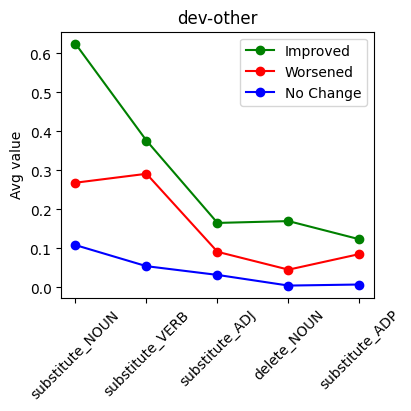

In [26]:
import matplotlib.pyplot as plt 

x = [ f"{i}_{j}" for i, j in top_k_columns.index.tolist()]
plt.figure(figsize=(4,4), constrained_layout=True)
plt.plot(x, tt1.loc[0, top_k_columns.index.tolist()].values, "g-o", label=f"Improved")
plt.plot(x, tt1.loc[1, top_k_columns.index.tolist()].values, "r-o", label=f"Worsened")
plt.plot(x, tt1.loc[2, top_k_columns.index.tolist()].values, "b-o", label=f"No Change")
plt.xticks(rotation=45)
plt.ylabel("Avg value")
# plt.title(f'top-{k} ChatGPT changes')
plt.title('dev-other')
plt.legend()
plt.savefig(f'top-{k}-dev-other-3-classes.png', bbox_inches='tight')